##### 실행 환경 설정

In [1]:
# Google Drive를 Colab에 마운트
from google.colab import drive
drive.mount("/google_drive")

from pathlib import Path
from urllib.request import urlretrieve
import zipfile
import yaml

# 작업 경로 설정
WORK_DIR = Path("/google_drive/Othercomputers/내 Mac/sec08")
if not WORK_DIR.exists():
    raise FileNotFoundError(f"작업 폴더를 찾을 수 없습니다: {WORK_DIR}")

print("\n[작업 폴더 목록]")
%cd {WORK_DIR}
!ls

# Colab 로컬 데이터셋 경로 설정
DATASET_PATH = Path("/datasets/construction-ppe")
DATASET_ZIP = Path("/datasets/construction-ppe.zip")
DATASET_URL = (
    "https://github.com/ultralytics/assets/"
    "releases/download/v0.0.0/construction-ppe.zip"
)

# 필수 데이터 파일이 없으면 데이터셋을 다운로드하고 압축 해제
DATASET_READY = all(
    (DATASET_PATH / relative_path).exists()
    for relative_path in ["data.yaml", "images/train", "labels/train"]
)

if not DATASET_READY:
    DATASET_PATH.mkdir(parents=True, exist_ok=True)
    print("\n데이터셋 다운로드 중...")
    urlretrieve(DATASET_URL, DATASET_ZIP)

    print("데이터셋 압축 해제 중...")
    with zipfile.ZipFile(DATASET_ZIP, "r") as zip_file:
        zip_file.extractall(DATASET_PATH)

    DATASET_ZIP.unlink(missing_ok=True)

print("\n[데이터셋 폴더 목록]")
print(DATASET_PATH)
!ls {DATASET_PATH}
print(DATASET_PATH / "images")
!ls {DATASET_PATH}/images
print(DATASET_PATH / "labels")
!ls {DATASET_PATH}/labels

# data.yaml의 path를 Colab 절대 경로로 변경
yaml_path = DATASET_PATH / "data.yaml"
with open(yaml_path, "r", encoding="utf-8") as file:
    cfg = yaml.safe_load(file)

cfg["path"] = str(DATASET_PATH)

with open(yaml_path, "w", encoding="utf-8") as file:
    yaml.safe_dump(cfg, file, allow_unicode=True, sort_keys=False)

print("\n[data.yaml]")
print(cfg)

# 한글 폰트 설치
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
!apt-get -qq install fonts-nanum
fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

Mounted at /google_drive

[작업 폴더 목록]
/google_drive/Othercomputers/내 Mac/sec08
01_object_detection_yolo_info.ipynb	      datasets
02_object_detection_yolo_dataset.ipynb	      detect
03_object_detection_yolo_train.ipynb	      runs
04_object_detection_yolo_visualization.ipynb  yolo11n.pt
05_segmentation_yolo_info.ipynb		      yolo11n-seg.pt
06_segmentation_yolo_train.ipynb	      yolo26n.pt
07_segmentation_yolo_visualization.ipynb      yolo26n-seg.pt

데이터셋 다운로드 중...
데이터셋 압축 해제 중...

[데이터셋 폴더 목록]
/datasets/construction-ppe
data.yaml  images  labels  LICENSE
/datasets/construction-ppe/images
test  train  val
/datasets/construction-ppe/labels
test  train  val

[data.yaml]
{'path': '/datasets/construction-ppe', 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'names': {0: 'helmet', 1: 'gloves', 2: 'vest', 3: 'boots', 4: 'goggles', 5: 'none', 6: 'Person', 7: 'no_helmet', 8: 'no_goggle', 9: 'no_gloves', 10: 'no_boots'}, 'download': 'https://github.com/ultralytics/assets/relea

##### 임포트

In [2]:
%pip install -q -U ultralytics

from ultralytics import YOLO
import torch
from pathlib import Path
from IPython.display import Image, display

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


##### Device 설정

In [3]:
# 100 epoch가 CPU에서 실행되지 않도록 Colab GPU 사용 여부 확인
if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU를 사용할 수 없습니다. Colab에서 런타임 > 런타임 유형 변경 > T4 GPU를 선택하세요."
    )

DEVICE = 0
print("사용 디바이스: cuda:0")
print("GPU 이름:", torch.cuda.get_device_name(0))

사용 디바이스: cuda:0
GPU 이름: Tesla T4


##### 모델 로드

In [4]:
# 사전 학습 가중치로 모델 로드
model = YOLO("yolo26n.pt")
model.info()

YOLO26n summary: 260 layers, 2,572,280 parameters, 0 gradients, 6.1 GFLOPs


(260, 2572280, 0, 6.1192448)

##### 파인튜닝하기

In [5]:
# 학습 결과를 Google Drive에 저장
PROJECT_DIR = Path(WORK_DIR) / "runs" / "detect"

train_results = model.train(
    data=str(DATASET_PATH / "data.yaml"),       # data.yaml 경로
    epochs=100,                                  # 훈련 에포크 수
    imgsz=640,                                   # 입력 이미지 크기
    batch=-1,                                    # GPU VRAM의 약 60% 기준 자동 계산
    lr0=0.001,                                   # 초기 학습률
    patience=10,                                 # Early Stopping
    device=DEVICE,                               # Colab T4: cuda:0
    workers=2,                                   # Colab 권장 워커 수
    project=str(PROJECT_DIR),                    # 결과 상위 폴더
    name="03",                                   # 실행 결과 폴더 이름
    exist_ok=True                                # 동일 폴더 재사용
)

RUN_DIR = Path(model.trainer.save_dir)
print("훈련 결과 저장 위치:", RUN_DIR)

Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/datasets/construction-ppe/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=03, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_

학습 결과 확인

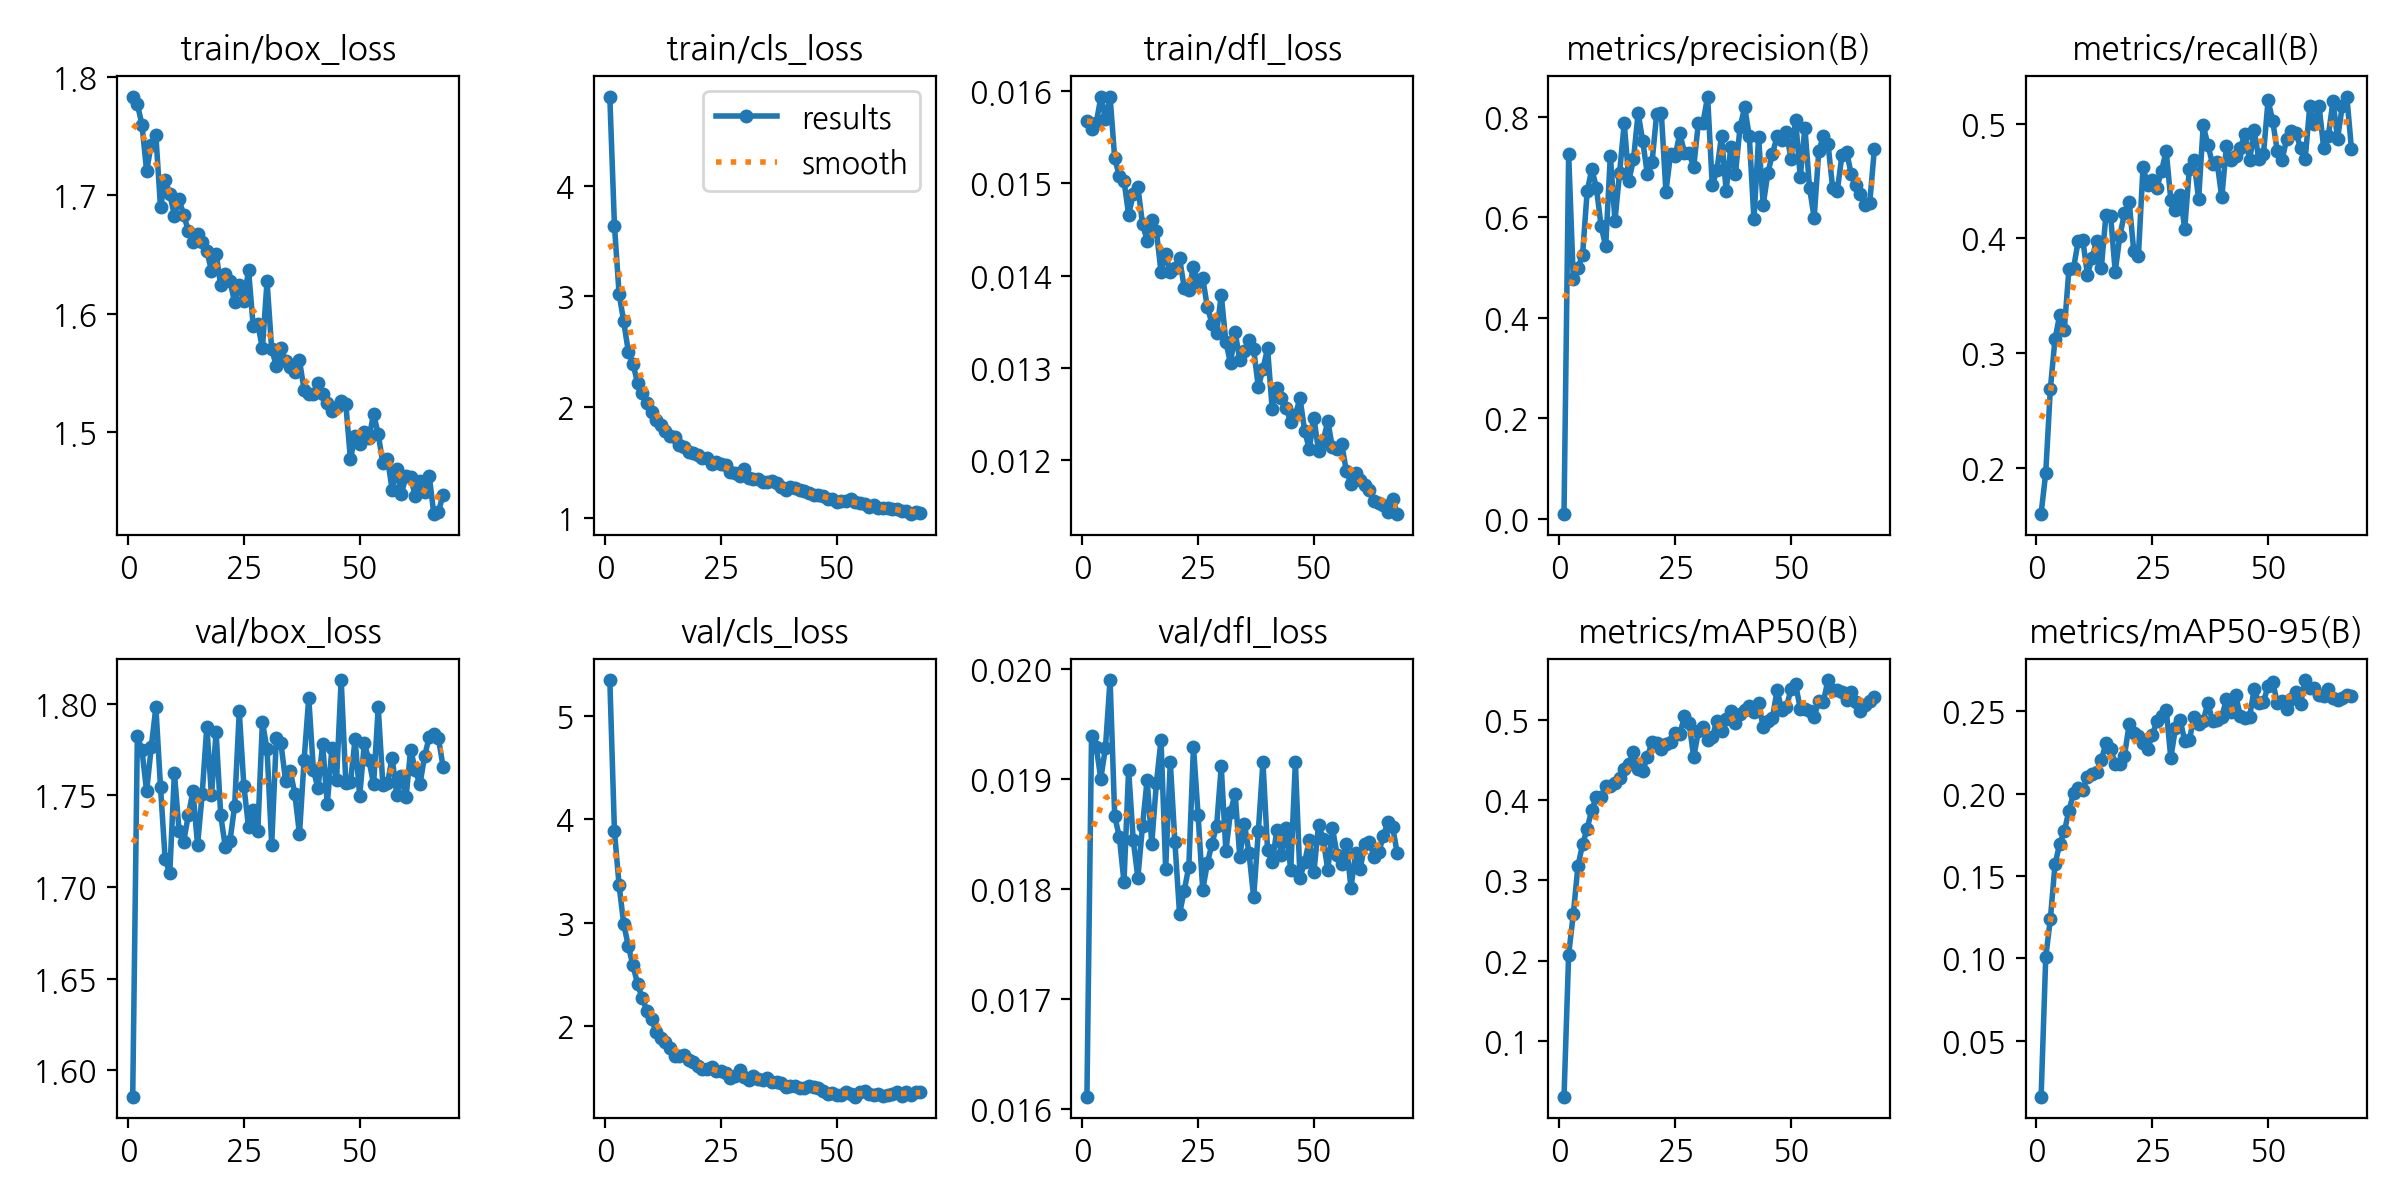

In [6]:
# 훈련/검증 손실 및 mAP 그래프
results_png_path = RUN_DIR / "results.png"
display(Image(filename=str(results_png_path)))

혼동 행렬  
- 정답, 오답, 못찾음(background)의 비율

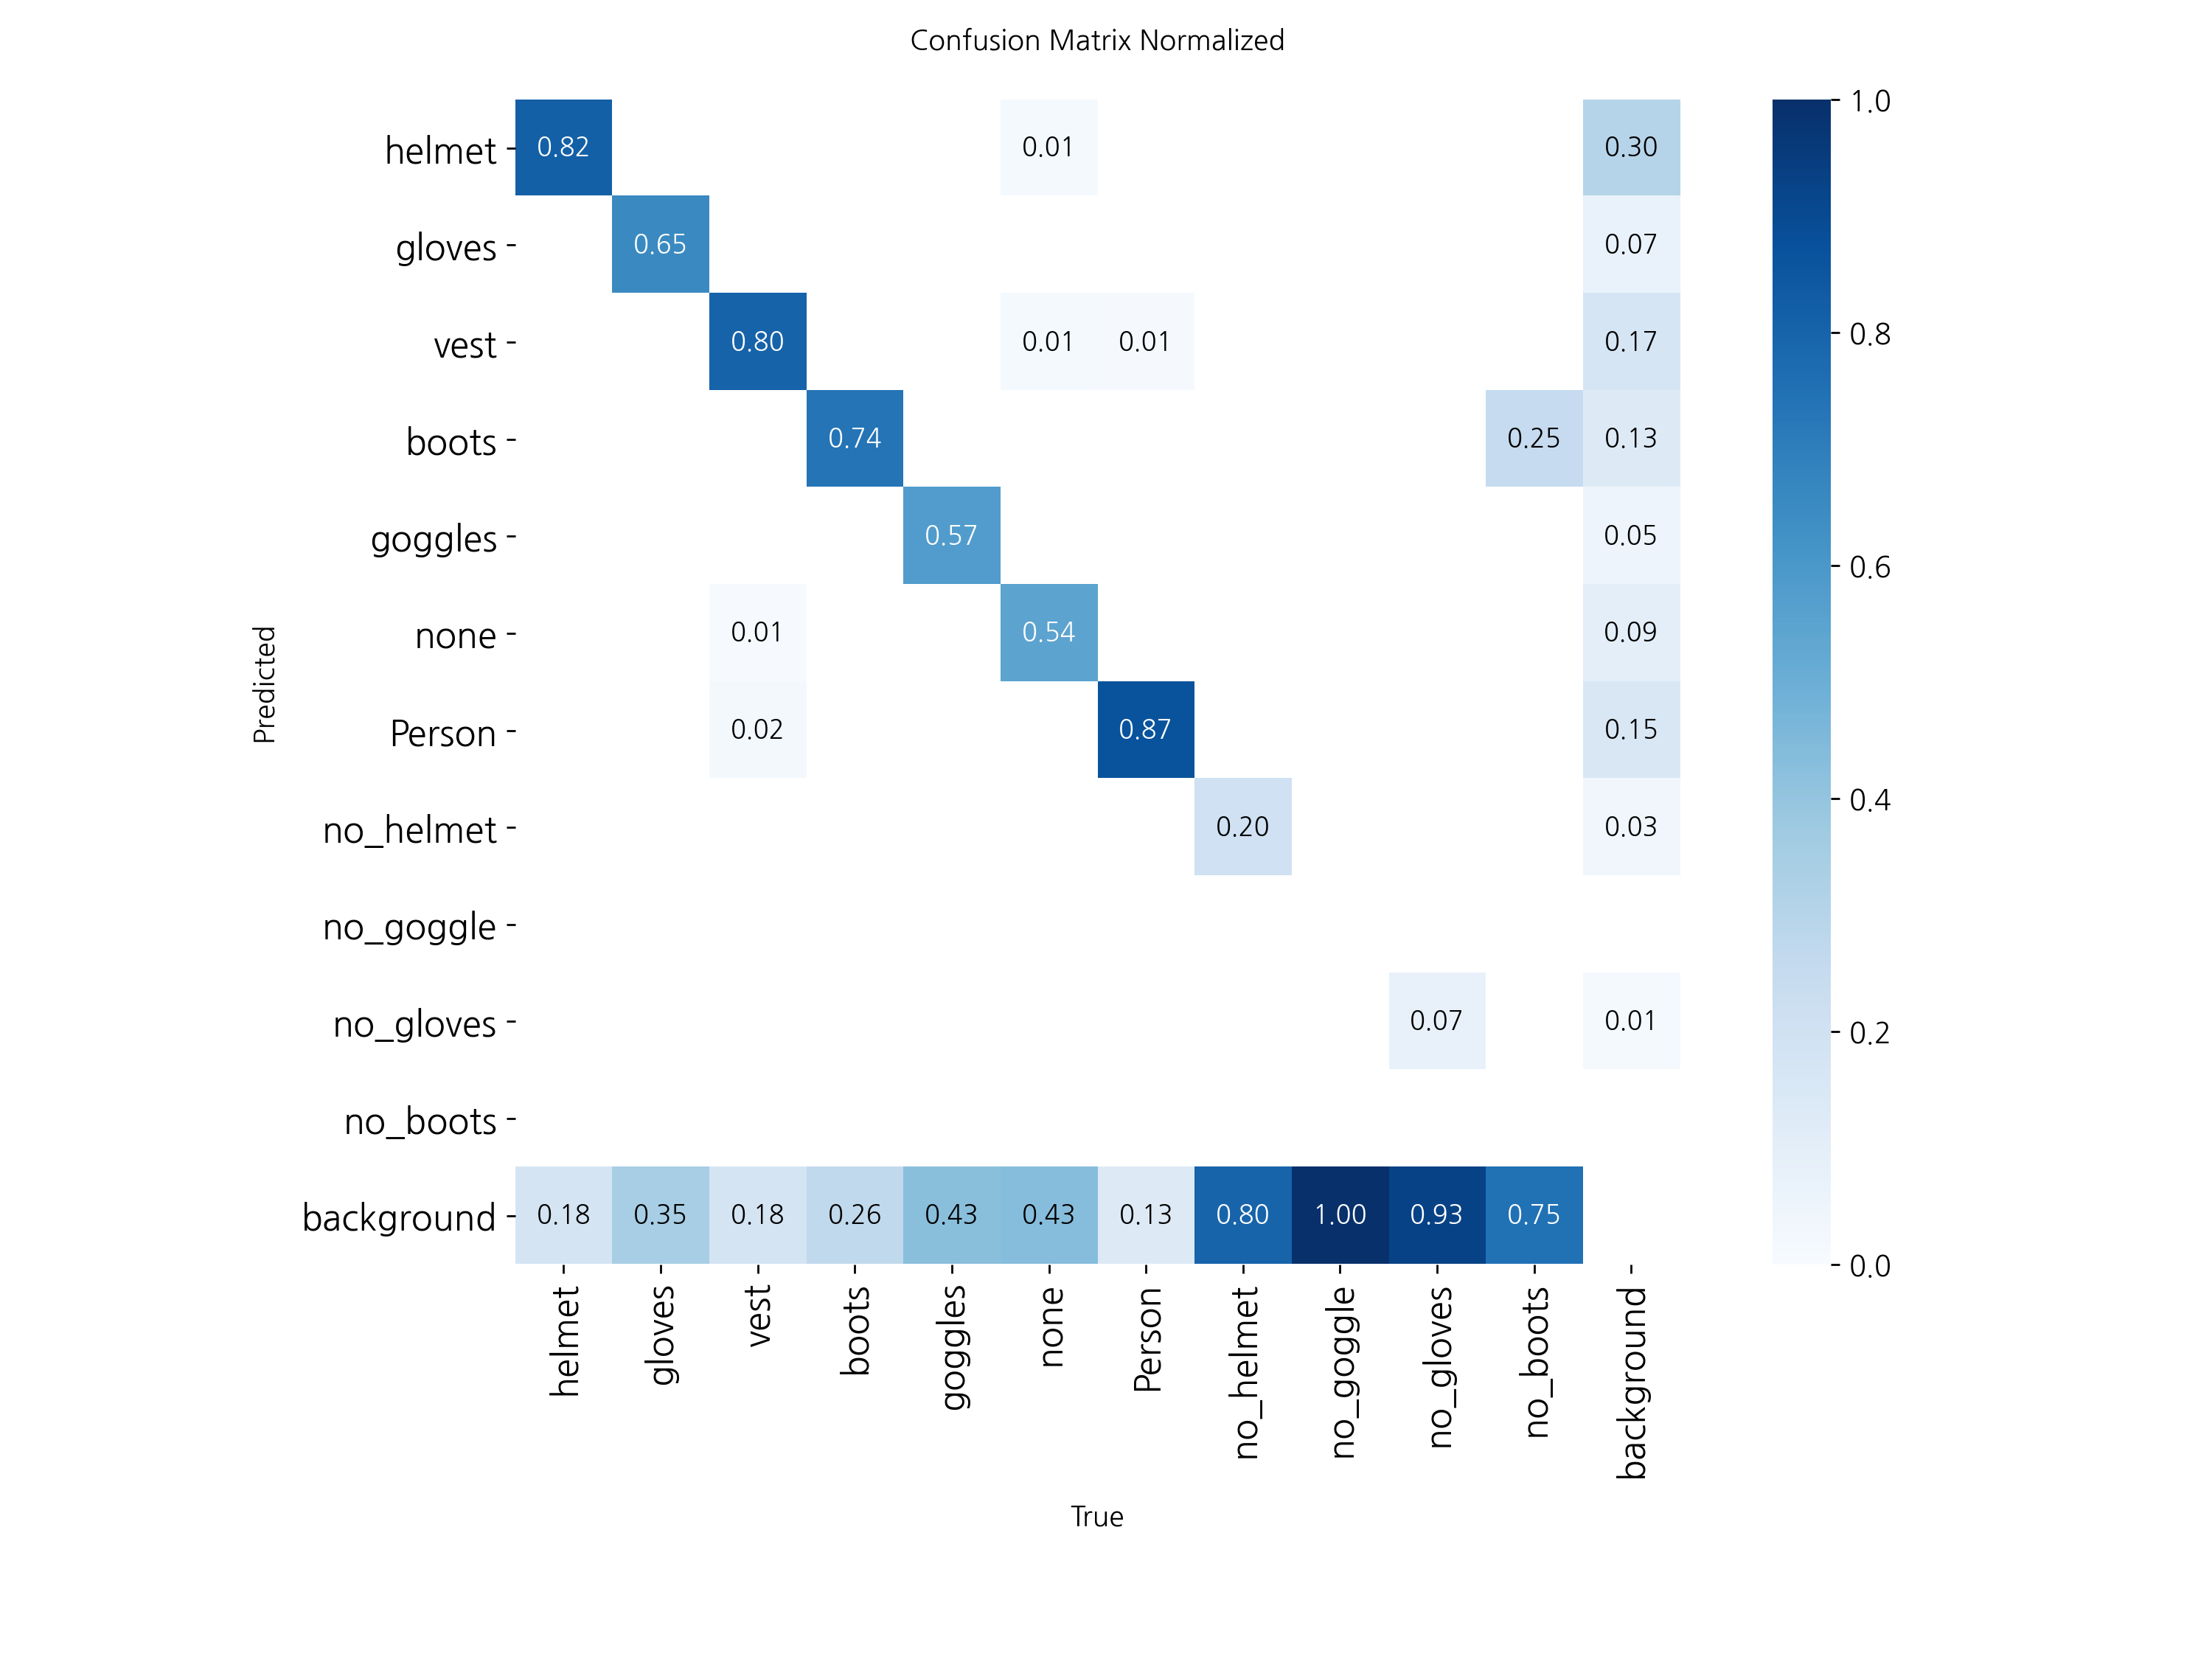

In [7]:
# Confusion Matrix 확인
confusion_matrix_png_path = RUN_DIR / "confusion_matrix_normalized.png"
display(Image(filename=str(confusion_matrix_png_path)))

모델 평가

In [8]:
# 최적 가중치(best.pt) 로드
best_model_path = RUN_DIR / "weights" / "best.pt"
best_model = YOLO(str(best_model_path))

# 테스트 데이터로 최종 평가
test_results = best_model.val(
    data=str(DATASET_PATH / "data.yaml"),
    split="test",
    device=DEVICE,
    project=str(RUN_DIR),
    name="test",
    exist_ok=True,
    verbose=False,
)

print(f"\nmAP50    : {test_results.box.map50:.4f}")
print(f"mAP50-95 : {test_results.box.map:.4f}")
print(f"Precision: {test_results.box.mp:.4f}")
print(f"Recall   : {test_results.box.mr:.4f}")

Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,376,981 parameters, 0 gradients, 5.2 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 26.7±22.2 MB/s, size: 153.4 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /datasets/construction-ppe/labels/test... 141 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 141/141 420.9it/s 0.3s
val: New cache created: /datasets/construction-ppe/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.2it/s 4.1s
                   all        141       1251      0.673      0.478      0.502      0.247
Speed: 5.1ms preprocess, 6.3ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /google_drive/Othercomputers/내 Mac/sec08/runs/detect/03/test

mAP50    : 0.502